# Deterministic-model verification: RMSE and extreme-event contingency metrics

This notebook scores a deterministic (single-valued) heat forecast against
observations, the deterministic counterpart to `ensemble_verification_metrics.md`
(which scores an *ensemble* forecast with coverage and the
probability-of-exceedance Brier score).

Two families of metrics, both computed at the grid-cell / day / lead-time
level and then reduced (summed or averaged) over whichever dimension you
choose:

- **RMSE** between the continuous forecast and observed values (Gneiting, 2011).
- **Contingency-table metrics** for the binary event `value > threshold`:
  hits (H), misses (M), false alarms (F), correct negatives (C), and the
  derived **POD**, **FAR**, **POFD**, and **SEDI** (Ferro & Stephenson, 2011).

The synthetic input cell below makes the notebook runnable as-is. Replace it
with your forecast and observation `xarray.DataArray` objects when using
real data -- everything downstream is unchanged.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from deterministic_metrics import (
    contingency_counts,
    deterministic_scores,
    false_alarm_ratio,
    probability_of_detection,
    probability_of_false_detection,
    rmse,
    symmetric_extremal_dependence_index,
)

variable = "t2m_max_6h"
forecast_days = 15
threshold = 32.0  # deg C, same exceedance threshold as the ensemble notebook's poe_threshold
region_name = "Delhi, India"

## Synthetic input arrays

Stand-ins for a deterministic model (e.g. a single high-resolution IFS/GFS
run) and ERA5 observations, with dims `time` (initialization),
`prediction_timedelta` (lead time), `latitude`, `longitude`. Forecast error
is grown with lead time so RMSE/SEDI-vs-lead curves below are non-trivial.

In [2]:
rng = np.random.default_rng(0)

n_init = 30
lead_days = np.arange(1, forecast_days + 1)
latitude = np.linspace(29.5, 27.5, 9)   # matches the Delhi, India region_bounds in the ensemble notebook
longitude = np.linspace(76.5, 78.5, 9)

time = xr.date_range("2026-06-01", periods=n_init, freq="D")
prediction_timedelta = (lead_days * np.timedelta64(1, "D")).astype("timedelta64[ns]")

dims = ("time", "prediction_timedelta", "latitude", "longitude")
coords = {"time": time, "prediction_timedelta": prediction_timedelta,
          "latitude": latitude, "longitude": longitude}
shape = tuple(len(coords[dim]) for dim in dims)

# Seasonal-ish baseline (function of initialization date only), broadcast to the full shape with plain numpy.
seasonal = 30 + 6 * np.sin(2 * np.pi * (time.dayofyear.values - 172) / 365)
truth = seasonal[:, None, None, None] * np.ones(shape)

observed = xr.DataArray(truth + rng.normal(0, 1.5, size=shape), dims=dims, coords=coords, name=variable)

# Forecast error grows with lead time, so RMSE/SEDI-vs-lead curves below are non-trivial.
lead_noise_scale = (0.5 + 0.35 * lead_days)[None, :, None, None]
forecast_noise = rng.normal(0, 1.0, size=shape) + rng.normal(0, 1.0, size=shape) * lead_noise_scale
forecast = xr.DataArray(truth + forecast_noise, dims=dims, coords=coords, name=variable)

observed

<xarray.DataArray 't2m_max_6h' (time: 30, prediction_timedelta: 15,
                                latitude: 9, longitude: 9)> Size: 292kB
array([[[[28.16345793, 27.77670531, 28.93549658, ..., 29.93086267,
          29.39548405, 26.91925975],
         [26.0767304 , 27.03995091, 28.03685157, ..., 26.87646157,
          27.15847413, 27.50041237],
         [28.59230841, 29.53863266, 27.78206061, ..., 29.33006787,
          28.11588105, 26.85961373],
         ...,
         [26.04232041, 28.56754569, 28.61965814, ..., 27.32020973,
          26.22015974, 30.58391442],
         [27.23099651, 28.46831705, 27.58700378, ..., 24.66959778,
          28.05290606, 29.00039189],
         [29.48080497, 27.04800204, 30.70787965, ..., 28.04844452,
          30.97845148, 28.25764139]],

        [[27.02507147, 27.40851734, 26.33814343, ..., 29.91670083,
          26.84295392, 30.50852378],
         [27.54378104, 30.33647502, 27.32568383, ..., 28.21637697,
          27.09656937, 25.96303303],
         [25.87258228, 28.72888688, 29.45943215, ..., 26.05427169,
          26.90526046, 28.90638938],
...
         [30.92283762, 29.4895415 , 30.34502447, ..., 29.48359153,
          30.6684712 , 30.00025241],
         [30.62543958, 28.07207267, 31.36728909, ..., 30.24036114,
          30.82453035, 32.7138862 ],
         [29.8583519 , 29.52929679, 31.27550989, ..., 33.03318076,
          30.96248148, 31.71323242]],

        [[30.85113775, 28.3796237 , 31.89745729, ..., 35.18867516,
          32.60192487, 30.30675715],
         [28.93204606, 31.74011215, 29.707187  , ..., 31.14554301,
          28.30598123, 30.83872548],
         [30.94156829, 32.11576048, 28.53945997, ..., 29.93598495,
          29.7520024 , 28.00574482],
         ...,
         [32.96230587, 32.42729054, 30.80743388, ..., 30.70454067,
          32.39310759, 31.78342757],
         [32.03194326, 30.11231237, 29.29909958, ..., 28.80067657,
          29.75807591, 34.24014644],
         [30.01313221, 29.06721769, 33.17040986, ..., 29.50771308,
          31.4077691 , 31.14846823]]]], shape=(30, 15, 9, 9))
Coordinates:
  * time                  (time) datetime64[ns] 240B 2026-06-01 ... 2026-06-30
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 120B 1 days ...
  * latitude              (latitude) float64 72B 29.5 29.25 29.0 ... 27.75 27.5
  * longitude             (longitude) float64 72B 76.5 76.75 77.0 ... 78.25 78.5

## Calculate per-case scores

`deterministic_scores` returns RMSE plus the four contingency counts and
their derived rates (POD, miss rate, FAR, POFD, SEDI) in one call. Pass
`dim="time"` to reduce over initializations only, keeping
`prediction_timedelta`, `latitude`, and `longitude` -- exactly like the
ensemble notebook's per-case scores, which leave the choice of aggregation
(map vs. lead-time) to downstream code.

In [3]:
per_case = deterministic_scores(forecast, observed, threshold, dim="time")

# Map: average/sum over initialization and lead time, keep space.
scores_map = deterministic_scores(forecast, observed, threshold, dim=("time", "prediction_timedelta"))

# Lead-time curve: average/sum over initialization and space, keep lead time.
scores_by_lead = deterministic_scores(forecast, observed, threshold, dim=("time", "latitude", "longitude"))

scores_by_lead

<xarray.Dataset> Size: 1kB
Dimensions:               (prediction_timedelta: 15)
Coordinates:
  * prediction_timedelta  (prediction_timedelta) timedelta64[ns] 120B 1 days ...
Data variables:
    hits                  (prediction_timedelta) int64 120B 20 21 25 ... 62 58
    misses                (prediction_timedelta) int64 120B 155 131 ... 113 101
    false_alarms          (prediction_timedelta) int64 120B 104 163 ... 711 751
    correct_negatives     (prediction_timedelta) int64 120B 2151 2115 ... 1520
    rmse                  (prediction_timedelta) float64 120B 1.983 ... 6.073
    pod                   (prediction_timedelta) float64 120B 0.1143 ... 0.3648
    miss_rate             (prediction_timedelta) float64 120B 0.8857 ... 0.6352
    far                   (prediction_timedelta) float64 120B 0.8387 ... 0.9283
    pofd                  (prediction_timedelta) float64 120B 0.04612 ... 0.3307
    sedi                  (prediction_timedelta) float64 120B 0.1813 ... 0.05063

## Map: RMSE and SEDI

Mirrors the ensemble notebook's coverage/Brier-score maps -- same
`region_name`/domain, deterministic metrics instead.

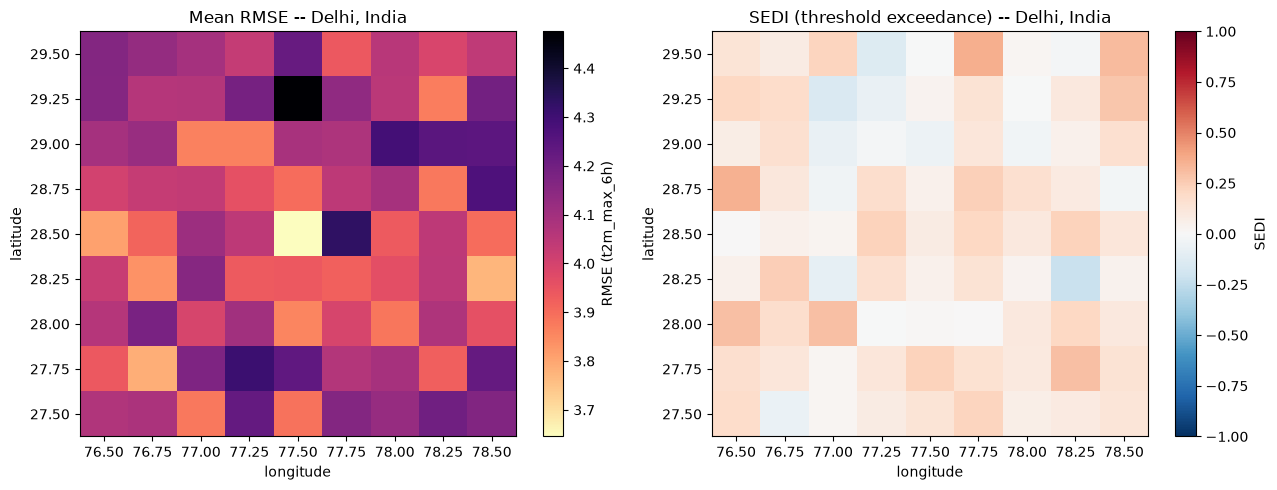

In [4]:
figure, axes = plt.subplots(ncols=2, figsize=(13, 5))

scores_map["rmse"].plot(ax=axes[0], x="longitude", y="latitude", cmap="magma_r",
                         cbar_kwargs={"label": f"RMSE ({variable})"})
scores_map["sedi"].plot(ax=axes[1], x="longitude", y="latitude", cmap="RdBu_r", vmin=-1, vmax=1,
                         cbar_kwargs={"label": "SEDI"})

for axis, title in zip(axes, ("Mean RMSE", "SEDI (threshold exceedance)")):
    axis.set_title(f"{title} -- {region_name}")

figure.tight_layout()

## Example: aggregate by lead time

Because `per_case` still carries `prediction_timedelta`, this is a
re-aggregation of already-computed per-case scores -- no need to
recompute RMSE or the contingency counts from scratch for a different view.

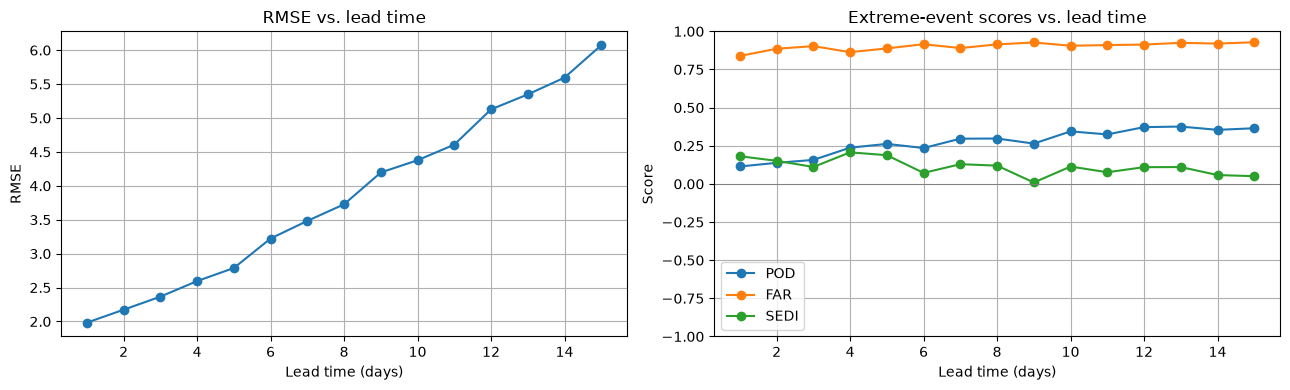

In [5]:
lead_days_axis = scores_by_lead.prediction_timedelta / np.timedelta64(1, "D")

figure, (rmse_axis, event_axis) = plt.subplots(ncols=2, figsize=(13, 4))

rmse_axis.plot(lead_days_axis, scores_by_lead["rmse"], marker="o")
rmse_axis.set(xlabel="Lead time (days)", ylabel="RMSE", title="RMSE vs. lead time")
rmse_axis.grid()

event_axis.plot(lead_days_axis, scores_by_lead["pod"], marker="o", label="POD")
event_axis.plot(lead_days_axis, scores_by_lead["far"], marker="o", label="FAR")
event_axis.plot(lead_days_axis, scores_by_lead["sedi"], marker="o", label="SEDI")
event_axis.set(xlabel="Lead time (days)", ylabel="Score", ylim=(-1, 1), title="Extreme-event scores vs. lead time")
event_axis.axhline(0, color="gray", linewidth=0.7)
event_axis.grid()
event_axis.legend()

figure.tight_layout()

## Worked check: contingency counts by hand

A small, fully worked example -- independent of the synthetic data above --
confirming `contingency_counts`, `probability_of_detection`,
`false_alarm_ratio`, `probability_of_false_detection`, and
`symmetric_extremal_dependence_index` match hand calculation. Useful as a
smoke test when wiring this module into a new pipeline.

In [6]:
example_forecast = xr.DataArray([10, 10, 1, 1, 10, 1, np.nan, 5], dims="x")
example_observed = xr.DataArray([10, 1, 10, 1, 1, 10, 10, np.nan], dims="x")
example_threshold = 5

# Pairs (forecast, observed) -> (forecast_extreme, observed_extreme):
# (10,10)->H  (10,1)->F  (1,10)->M  (1,1)->C  (10,1)->F  (1,10)->M  (nan,10)->excluded  (5,nan)->excluded
# So by hand: H=1, M=2, F=2, C=1
example_counts = contingency_counts(example_forecast, example_observed, example_threshold)
print("counts:", {name: int(value) for name, value in example_counts.data_vars.items()})
assert (int(example_counts["hits"]), int(example_counts["misses"]),
        int(example_counts["false_alarms"]), int(example_counts["correct_negatives"])) == (1, 2, 2, 1)

print("POD  :", float(probability_of_detection(example_counts)), "expected", 1 / 3)
print("FAR  :", float(false_alarm_ratio(example_counts)), "expected", 2 / 3)
print("POFD :", float(probability_of_false_detection(example_counts)), "expected", 2 / 3)

H, F = 1 / 3, 2 / 3
expected_sedi = (np.log(F) - np.log(H) - np.log(1 - F) + np.log(1 - H)) / \
                (np.log(F) + np.log(H) + np.log(1 - F) + np.log(1 - H))
print("SEDI :", float(symmetric_extremal_dependence_index(example_counts)), "expected", expected_sedi)

counts: {'hits': 1, 'misses': 2, 'false_alarms': 2, 'correct_negatives': 1}
POD  : 0.3333333333333333 expected 0.3333333333333333
FAR  : 0.6666666666666666 expected 0.6666666666666666
POFD : 0.6666666666666666 expected 0.6666666666666666
SEDI : -0.4608454206183703 expected -0.4608454206183703
